In [3]:
#Importação
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('PS4_GamesSales.csv', encoding='latin-1')

df.head()

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80


In [5]:
df.shape

(1034, 9)

In [6]:
# Nulos
df.isnull().sum()

Game               0
Year             209
Genre              0
Publisher        209
North America      0
Europe             0
Japan              0
Rest of World      0
Global             0
dtype: int64

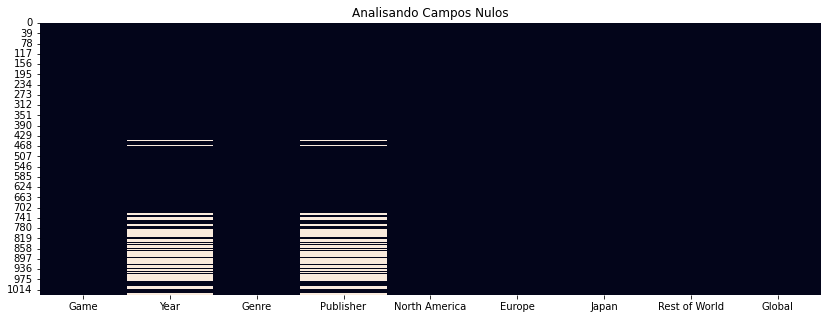

In [7]:
# Nulos Grafic
plt.figure(figsize=(14,5))
plt.title('Analisando Campos Nulos')
sns.heatmap( df.isnull(), cbar=False);

In [13]:
#Retirando Valores Nulos
df = df.dropna()
df.shape

(825, 9)

In [14]:
df.describe()

,Year,North America,Europe,Japan,Rest of World,Global
count,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000
mean,2015.966061,0.256448,0.311600,0.042048,0.111552,0.721721
std,1.298360,0.620259,0.868271,0.119814,0.274713,1.743122
min,2013.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,0.000000,0.000000,0.000000,0.000000,0.030000
50%,2016.000000,0.050000,0.020000,0.000000,0.020000,0.120000
75%,2017.000000,0.190000,0.220000,0.040000,0.090000,0.560000
max,2020.000000,6.180000,9.710000,2.170000,3.020000,19.390000


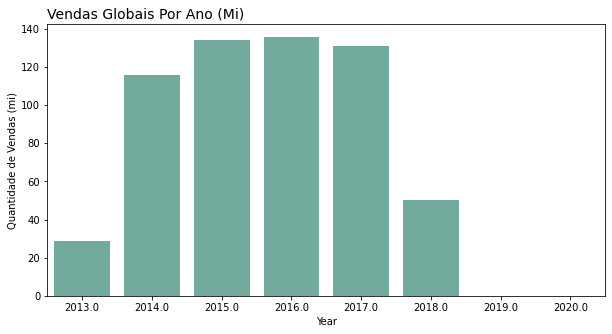

In [24]:
#Tamanho
plt.figure(figsize=(10,5))

#Titulo
plt.title('Vendas Globais Por Ano (Mi)', loc='left', fontsize=14)

#Gráfico
sns.barplot(data=df,x='Year',y='Global', ci=None, color='#69b3a2', estimator=sum);
plt.ylabel('Quantidade de Vendas (mi)');

In [27]:
# Retirar Anos
df = df.loc[ (df['Year'] != 2019) &  (df['Year'] != 2020)]
df.head()

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80


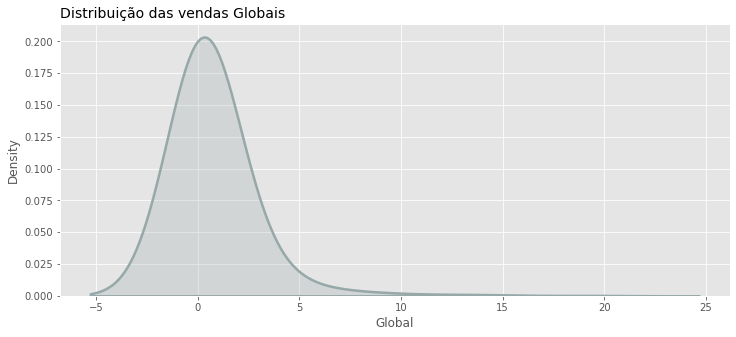

In [31]:
# Tamanho
plt.figure(figsize=(12,5))

#Estilo
plt.style.use('ggplot')

#Titulo
plt.title('Distribuição das vendas Globais', loc='left', fontsize=14)

#Plot
sns.kdeplot(df['Global'], shade=True, bw=1, color='#96a8a8', linewidth=2.5);


In [33]:
df.groupby(by=['Year']).sum().reset_index()

,Year,North America,Europe,Japan,Rest of World,Global
0,2013.0,10.35,12.88,0.97,4.57,28.76
1,2014.0,39.80,54.12,3.58,18.29,115.85
2,2015.0,49.60,56.21,7.28,20.88,133.99
3,2016.0,47.40,57.98,9.65,20.71,135.72
4,2017.0,44.77,57.18,9.08,19.89,130.90
5,2018.0,19.65,18.70,4.13,7.69,50.20


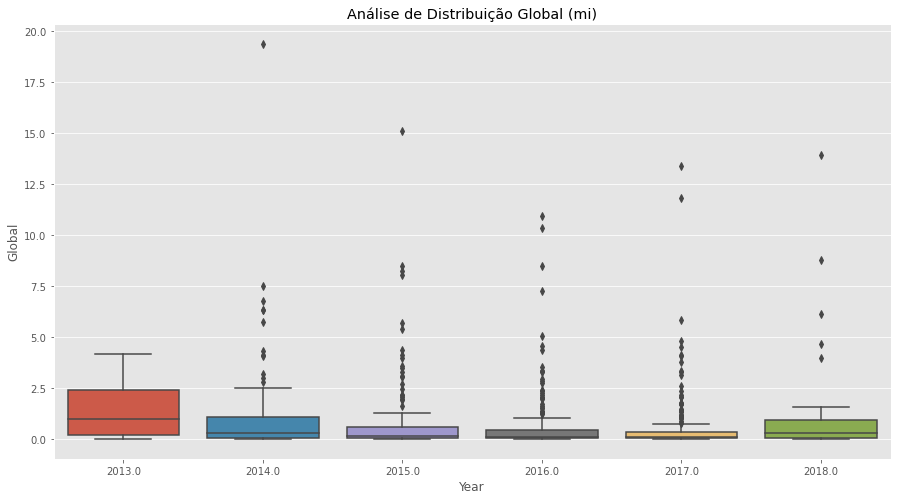

In [37]:
#Tamanho
plt.figure(figsize=(15,8))

#Gráfico
plt.title('Análise de Distribuição Global (mi)')
sns.boxplot(data=df,x='Year',y='Global');

In [38]:
df.groupby(by=['Genre']).sum().reset_index()

,Genre,Year,North America,Europe,Japan,Rest of World,Global
0,Action,407224.0,48.15,57.51,10.27,20.76,136.82
1,Action-Adventure,74580.0,22.30,27.79,1.96,9.83,61.86
2,Adventure,141128.0,5.27,6.08,1.64,2.23,15.22
3,Fighting,64506.0,8.58,6.11,1.67,2.97,19.36
4,MMO,14108.0,1.32,1.45,0.20,0.55,3.52
5,Misc,100754.0,3.64,6.03,0.96,1.85,12.47
6,Music,36281.0,2.40,1.62,0.17,0.84,5.03
7,Party,4034.0,0.09,0.47,0.00,0.10,0.65
8,Platform,64506.0,5.48,8.92,0.67,2.77,17.85
9,Puzzle,20154.0,0.28,0.16,0.00,0.10,0.52


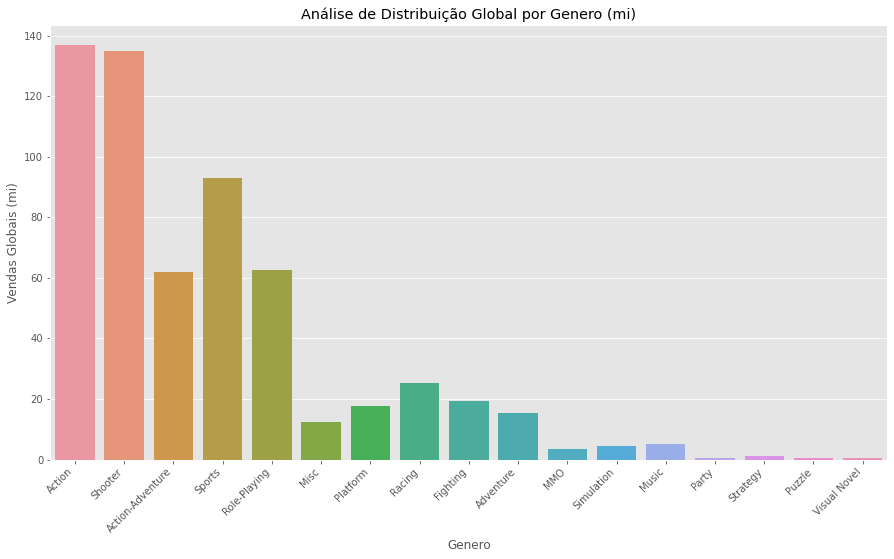

In [45]:
#Tamanho
plt.figure(figsize=(15,8))

#Gráfico
plt.title('Análise de Distribuição Global por Genero (mi)')
sns.barplot(data=df,x='Genre',y='Global', ci=None,  estimator=sum);
plt.xlabel('Genero');
plt.ylabel('Vendas Globais (mi)')
plt.xticks(rotation=45,ha='right');